In [1]:
"""
Cavity regime diagram — Figure 8 recreation
============================================
Data digitised with WebPlotDigitizer from:
  "Regime diagram indicating the dependence of the observed cavity type
   on B and W for θ_a = 120°"

Symbols / regimes:
  ▲  Quasi-static  (blue)   — below solid curve
  ✱  Shallow seal  (green)  — between solid and dash-dot lines
  ●  Deep seal     (amber)  — between dash-dot and dashed lines
  ♦  Surface seal  (red)    — above dashed line

Boundary lines (approximate spline fits, not exact analytical curves):
  solid      W = 320 (horizontal, low B) — quasi-static ↔ shallow seal
  dash-dot   — shallow seal ↔ deep seal
  dashed     W = 320 (horizontal) then rising — deep seal ↔ surface seal
              High-B branch follows Birkhoff & Isaacs (1951)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import make_interp_spline
import warnings; warnings.filterwarnings('ignore')

# ── Load digitised data from WebPlotDigitizer CSV ────────────────────────────
def load_wpd(path):
    df = pd.read_csv(path, header=1)
    df.columns = ['Qs_B', 'Qs_W', 'Sh_B', 'Sh_W', 'De_B', 'De_W', 'Su_B', 'Su_W']
    def pts(bk, wk):
        return np.column_stack([df[bk].dropna().values, df[wk].dropna().values])
    return pts('Qs_B','Qs_W'), pts('Sh_B','Sh_W'), pts('De_B','De_W'), pts('Su_B','Su_W')

triangles, asterisks, circles, diamonds = load_wpd('/Users/alokbharadwaj/Downloads/wpd_datasets.csv')


In [28]:

# ── Boundary line control points ──────────────────────────────────────────────
B_solid = np.array([0.05, 1.4, 7.0, 12.0])
W_solid = np.array([4.0,  2,  4.0, 6.0])

B_dd    = np.array([0.05, 7, 12])
W_dd    = np.array([85,   4, 6])

B_dash  = np.array([0.05, 3, 12])
W_dash  = np.array([320,  320, 1450])



In [29]:

def smooth_line(Bpts, Wpts, n=500):
    logB = np.log10(Bpts); logW = np.log10(Wpts)
    t = np.linspace(0, 1, len(Bpts)); tf = np.linspace(0, 1, n)
    k = min(3, len(Bpts) - 1)
    return (10**make_interp_spline(t, logB, k=k)(tf),
            10**make_interp_spline(t, logW, k=k)(tf))


def ilog(Bn, Br, Wr):
    """Interpolate in log-log space."""
    return 10**np.interp(np.log10(Bn), np.log10(Br), np.log10(Wr))



In [30]:

Bs, Ws   = smooth_line(B_solid, W_solid, n=30)
Bdd, Wdd = smooth_line(B_dd,    W_dd, n=3)
Bd, Wd   = smooth_line(B_dash,  W_dash, n=3)



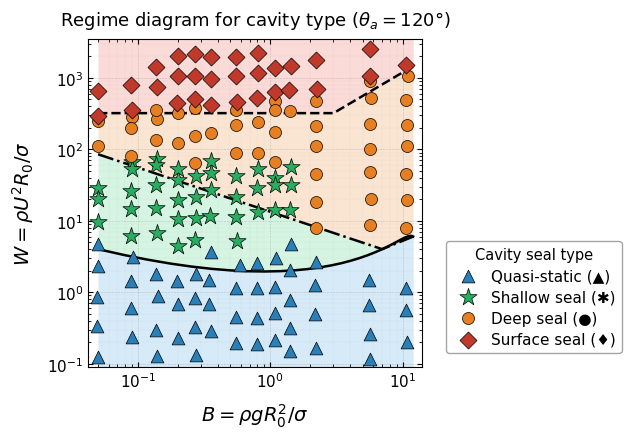

In [32]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.042, 14); ax.set_ylim(0.09, 3500)
W_bot, W_top = 0.09, 3500

B1 = np.logspace(np.log10(max(Bs.min(), Bdd.min())),
                  np.log10(min(Bs.max(), Bdd.max())), 500)
B2 = np.logspace(np.log10(max(Bdd.min(), Bd.min())),
                  np.log10(min(Bdd.max(), Bd.max())), 500)

alpha = 0.20
ax.fill_between(Bs, W_bot,             Ws,                  alpha=alpha, color='#3498DB', lw=0, zorder=0)
ax.fill_between(B1, ilog(B1, Bs, Ws),  ilog(B1, Bdd, Wdd),  alpha=alpha, color='#2ECC71', lw=0, zorder=0)
ax.fill_between(B2, ilog(B2, Bdd, Wdd),ilog(B2, Bd,  Wd),   alpha=alpha, color='#E67E22', lw=0, zorder=0)
ax.fill_between(Bd, Wd,                W_top,               alpha=alpha, color='#E74C3C', lw=0, zorder=0)

ax.grid(True, which='major', ls='--', lw=0.4, color='gray', alpha=0.4, zorder=1)
ax.grid(True, which='minor', ls=':',  lw=0.3, color='gray', alpha=0.25, zorder=1)

ax.plot(Bs,  Ws,  'k-',  lw=1.8, zorder=4)
ax.plot(Bdd, Wdd, 'k-.', lw=1.8, zorder=4)
ax.plot(Bd,  Wd,  'k--', lw=1.8, zorder=4)

kw = dict(edgecolors='k', linewidths=0.5, zorder=6)
ax.scatter(*triangles.T, marker='^', s=85,  c='#2980B9', label='Quasi-static (▲)',  **kw)
ax.scatter(*asterisks.T, marker='*', s=170, c='#27AE60', label='Shallow seal (✱)', **kw)
ax.scatter(*circles.T,   marker='o', s=75,  c='#E67E22', label='Deep seal (●)',     **kw)
ax.scatter(*diamonds.T,  marker='D', s=75,  c='#C0392B', label='Surface seal (♦)',  **kw)

lkw = dict(fontsize=10.5, ha='center', alpha=0.72, style='italic')
ax.set_xlabel(r'$B = \rho g R_0^2 / \sigma$', fontsize=14, labelpad=8)
ax.set_ylabel(r'$W = \rho U^2 R_0 / \sigma$', fontsize=14, labelpad=8)
ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=11)
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

ax.legend(fontsize=11, loc='lower left', framealpha=0.88, edgecolor='0.6',
          title='Cavity seal type', title_fontsize=10.5,
          handletextpad=0.5, labelspacing=0.4, bbox_to_anchor=(1.05, 0.02))
ax.set_title(r'Regime diagram for cavity type ($\theta_a = 120°$)',
             fontsize=13, pad=10)

plt.tight_layout()
plt.savefig('cavity_regime_diagram_wpd.pdf', dpi=600, bbox_inches='tight')
plt.savefig('cavity_regime_diagram_wpd.png', dpi=600, bbox_inches='tight')
plt.show()